# E-Commerce CUstomer Purchase Prediction

## Objective

The obkective of this project is to analyze online shopping session data and develop a machine learning model that predicts whether a visitor will make a purchase during a browsing session

### Target Variable

`Revenue`

### Dataset

UCI Online Shopper Purchasing Intention Dataset

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")



In [24]:
from src.data.load import load_raw_data

df = load_raw_data()

df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [25]:
print(f"number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
df.shape


number of rows: 12330
Number of columns: 18


(12330, 18)

In [26]:
df.columns

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Revenue'],
      dtype='str')

In [27]:
df.sample(5, random_state = 42)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
8916,3,142.500000,0,0.00,48,1052.255952,0.004348,0.013043,0.000000,0.0,Nov,1,8,6,11,Returning_Visitor,False,False
772,6,437.391304,2,235.55,83,2503.881781,0.002198,0.004916,2.086218,0.0,Mar,2,2,3,2,Returning_Visitor,False,True
12250,1,41.125000,0,0.00,126,4310.004668,0.000688,0.012823,3.451072,0.0,Nov,2,2,2,2,Returning_Visitor,False,False
7793,2,141.000000,0,0.00,10,606.666667,0.008333,0.026389,36.672294,0.0,Aug,2,5,7,4,Returning_Visitor,False,False
6601,18,608.140000,6,733.80,168,4948.398759,0.006632,0.013528,10.150644,0.0,Aug,2,2,3,1,Returning_Visitor,True,False


In [28]:
df.tail()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,Dec,4,6,1,1,Returning_Visitor,True,False
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,Nov,3,2,1,8,Returning_Visitor,True,False
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,Nov,3,2,1,13,Returning_Visitor,True,False
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,Nov,2,2,3,11,Returning_Visitor,False,False
12329,0,0.0,0,0.0,3,21.250000,0.000000,0.066667,0.000000,0.0,Nov,3,2,1,2,New_Visitor,True,False


In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

In [30]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [31]:
df.describe(include="object")

,Month,VisitorType
count,12330,12330
unique,10,3
top,May,Returning_Visitor
freq,3364,10551


In [32]:
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [33]:
df.duplicated().sum()

np.int64(125)

In [34]:
df["Revenue"].value_counts()

Revenue
False    10422
True      1908
Name: count, dtype: int64

In [35]:
df["Revenue"].value_counts(normalize=True) * 100

Revenue
False    84.525547
True     15.474453
Name: proportion, dtype: float64

In [38]:
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()

numerical_columns

['Administrative',
 'Administrative_Duration',
 'Informational',
 'Informational_Duration',
 'ProductRelated',
 'ProductRelated_Duration',
 'BounceRates',
 'ExitRates',
 'PageValues',
 'SpecialDay',
 'OperatingSystems',
 'Browser',
 'Region',
 'TrafficType']

In [39]:
categorical_columns = df.select_dtypes(include = ["object", "bool"]).columns.tolist()

categorical_columns

['Month', 'VisitorType', 'Weekend', 'Revenue']

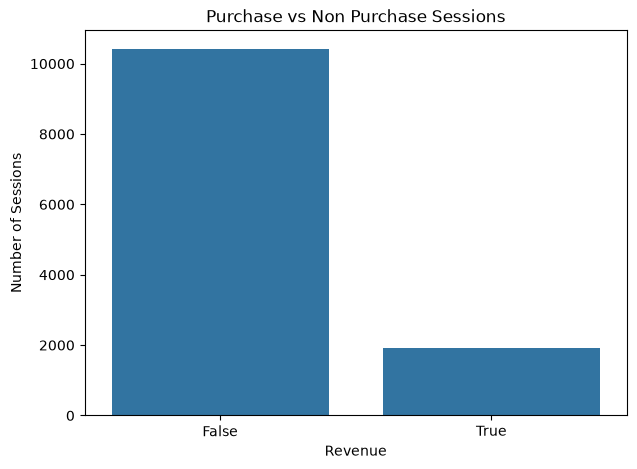

In [42]:
plt.figure(figsize = (7,5))
sns.countplot(data = df, x ="Revenue")

plt.title("Purchase vs Non Purchase Sessions")
plt.xlabel("Revenue")
plt.ylabel("Number of Sessions")

plt.show()



In [50]:
print(f"the unique months we have: {df["Month"].unique()} \n")

print(f"The unique value of the visitor types we have: {df["VisitorType"].unique()}")



the unique months we have: <StringArray>
['Feb', 'Mar', 'May', 'Oct', 'June', 'Jul', 'Aug', 'Nov', 'Sep', 'Dec']
Length: 10, dtype: str 

The unique value of the visitor types we have: <StringArray>
['Returning_Visitor', 'New_Visitor', 'Other']
Length: 3, dtype: str


In [51]:
revenue_percentage = (
    df["Revenue"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

revenue_percentage

Revenue
False    84.53
True     15.47
Name: proportion, dtype: float64

In [57]:
duplicates = df.duplicated().sum()
duplicates

print("\n")

df["Revenue"].value_counts(normalize= True).mul(100).round(2)


Revenue
False    84.53
True     15.47
Name: proportion, dtype: float64

## Univariate Analysis 

Univariate analysis examines the distribution and characterstics of individual variables before investigating realtionhsips between them.

In [59]:
numerical_columns

['Administrative',
 'Administrative_Duration',
 'Informational',
 'Informational_Duration',
 'ProductRelated',
 'ProductRelated_Duration',
 'BounceRates',
 'ExitRates',
 'PageValues',
 'SpecialDay',
 'OperatingSystems',
 'Browser',
 'Region',
 'TrafficType']

In [60]:
continuous_columns = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay"
]

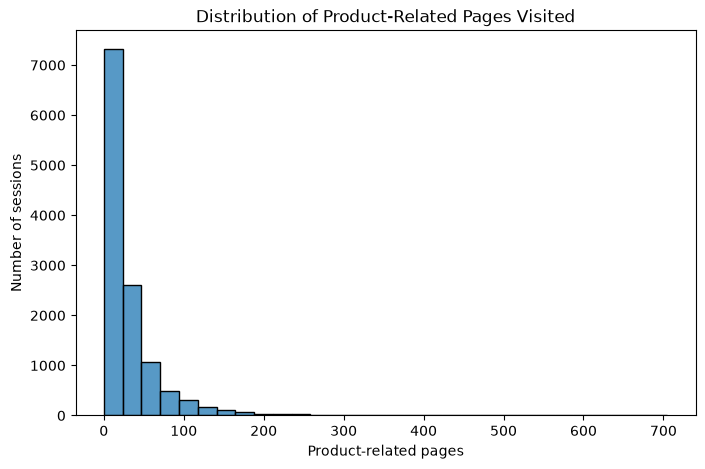

In [63]:
plt.figure(figsize=(8,5))
sns.histplot(data = df, x = "ProductRelated", bins = 30)

plt.title("Distribution of Product-Related Pages Visited")
plt.xlabel("Product-related pages")
plt.ylabel("Number of sessions")

plt.show()

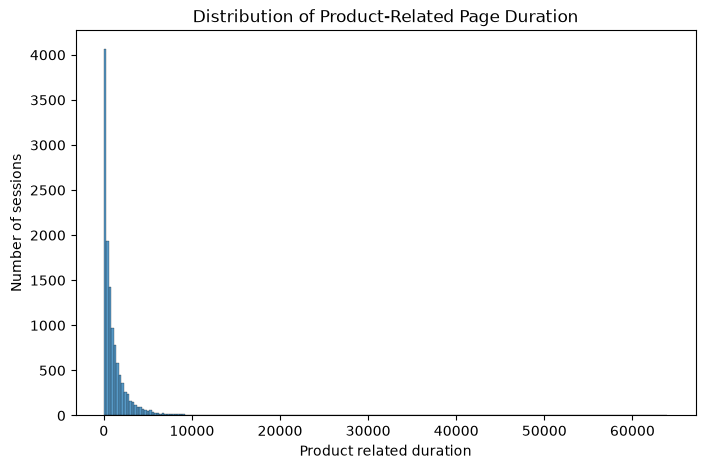

In [64]:
plt.figure(figsize=(8,5))
sns.histplot(data = df, x="ProductRelated_Duration")

plt.title("Distribution of Product-Related Page Duration")
plt.xlabel("Product related duration")
plt.ylabel("Number of sessions")

plt.show()


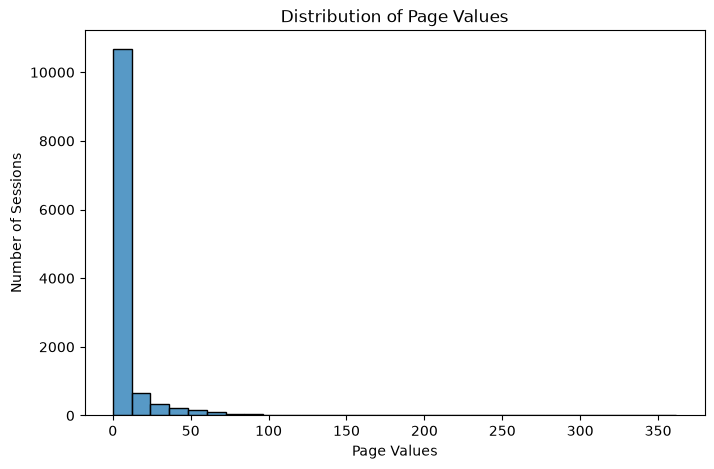

In [65]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="PageValues", bins=30)

plt.title("Distribution of Page Values")
plt.xlabel("Page Values")
plt.ylabel("Number of Sessions")

plt.show()

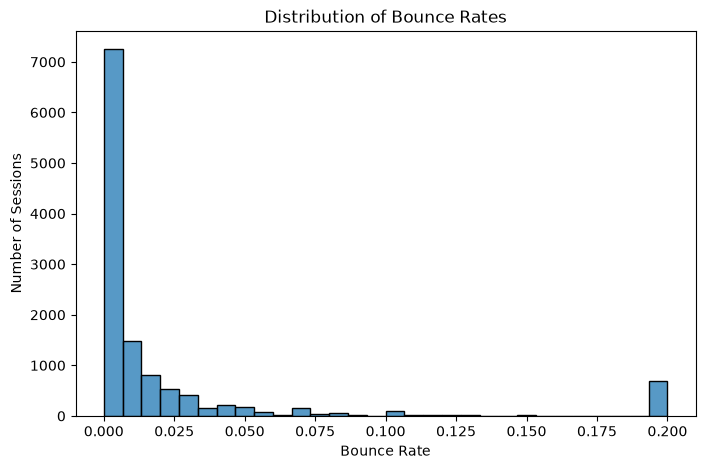

In [67]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="BounceRates", bins=30)

plt.title("Distribution of Bounce Rates")
plt.xlabel("Bounce Rate")
plt.ylabel("Number of Sessions")

plt.show()

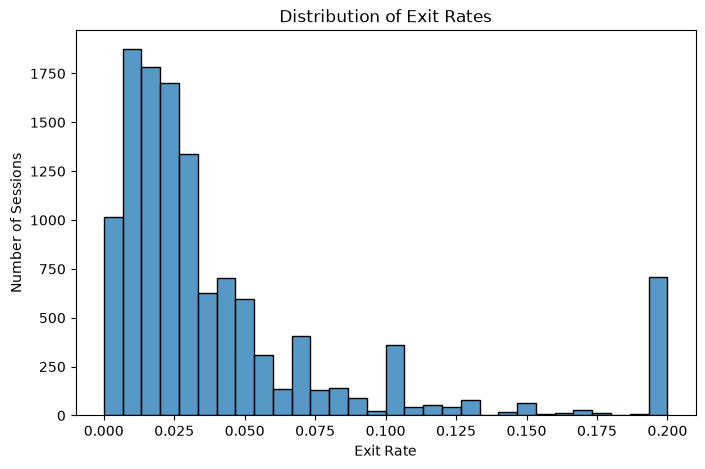

In [68]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="ExitRates", bins=30)

plt.title("Distribution of Exit Rates")
plt.xlabel("Exit Rate")
plt.ylabel("Number of Sessions")

plt.show()


### Observation

The `ProductRelated` variable is concetrated toward lower values, with a smaller number of sessions having substantially higher product-page activity. The distribution appears left-skewed.

In [69]:
skewness = df[continuous_columns].skew().sort_values(ascending=False)

skewness

Informational_Duration     7.579185
ProductRelated_Duration    7.263228
PageValues                 6.382964
Administrative_Duration    5.615719
ProductRelated             4.341516
Informational              4.036464
SpecialDay                 3.302667
BounceRates                2.947855
ExitRates                  2.148789
Administrative             1.960357
dtype: float64

## Outlier Analysis

Outlier analysis is performed to identify unsually large or small observations in numerical variables. Outliers will not be removed automatically, their impact and validity will be investigated before making any cleaning decisions.


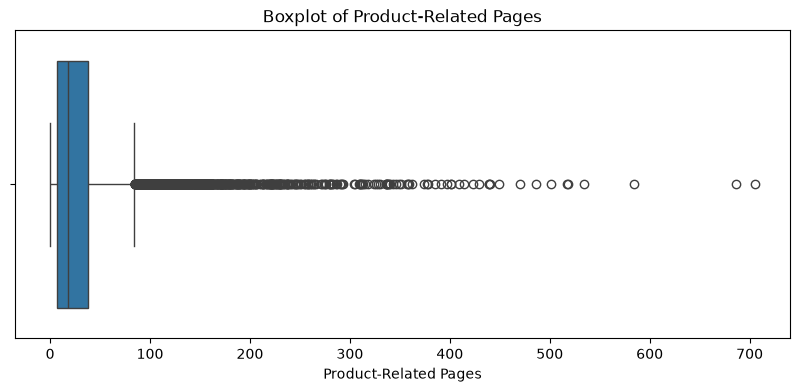

In [70]:
plt.figure(figsize=(10, 4))

sns.boxplot(data=df, x="ProductRelated")

plt.title("Boxplot of Product-Related Pages")
plt.xlabel("Product-Related Pages")

plt.show()

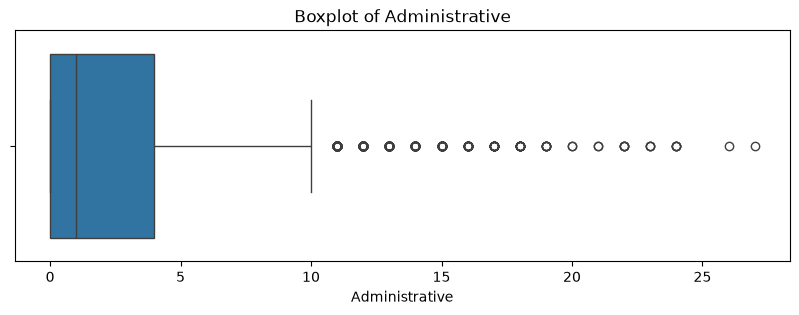

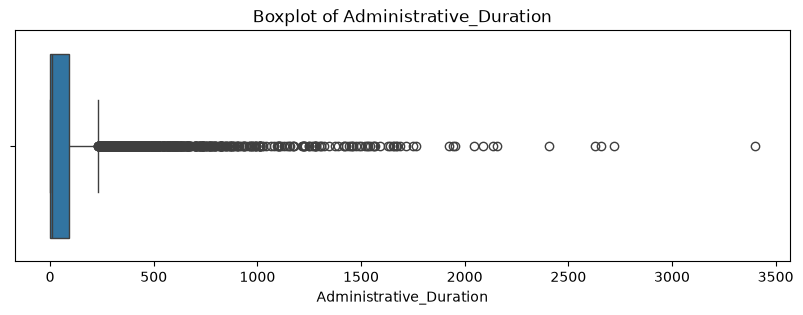

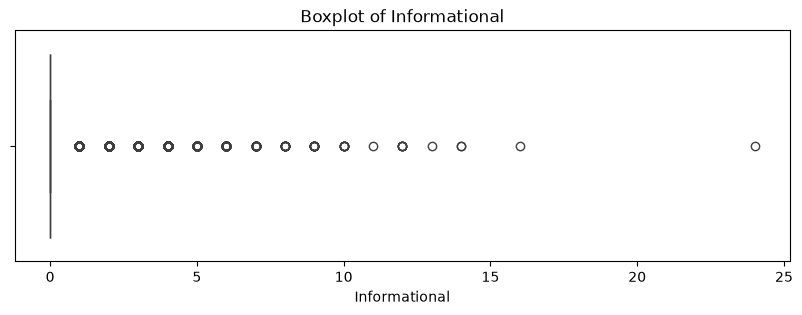

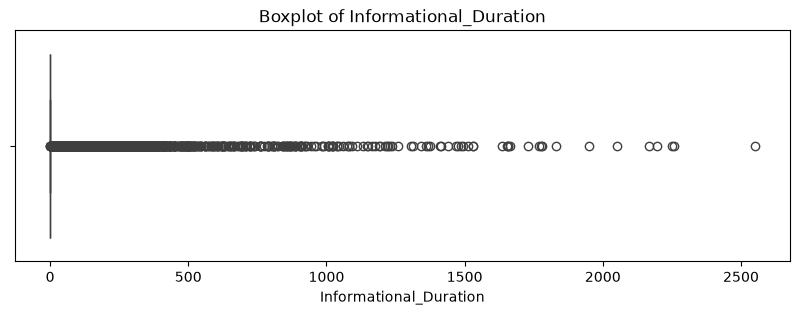

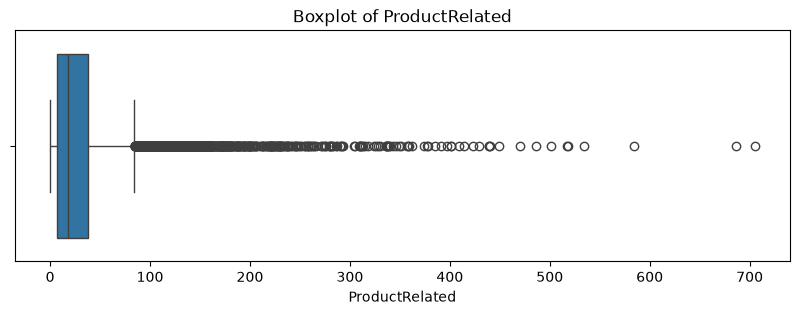

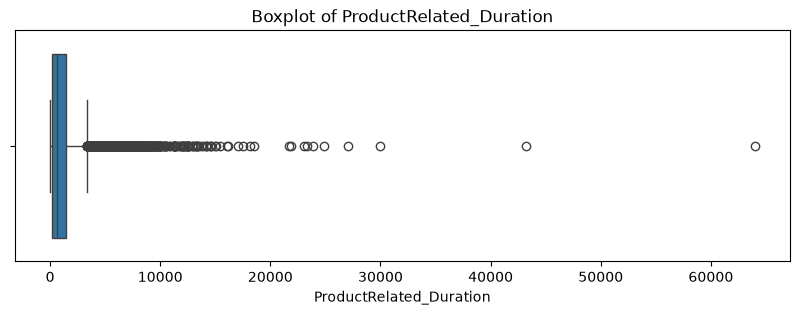

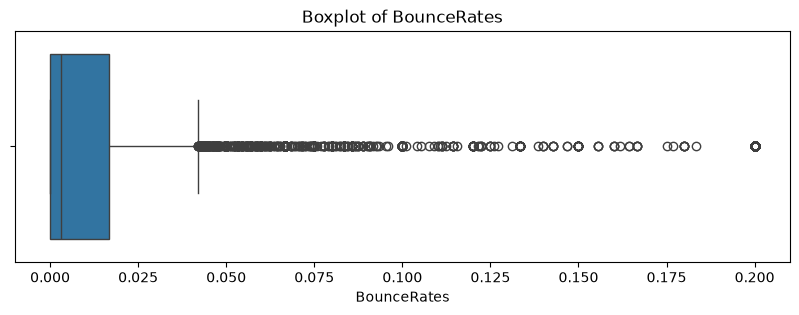

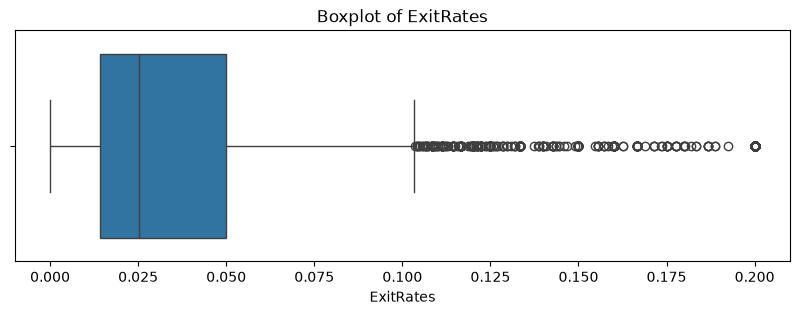

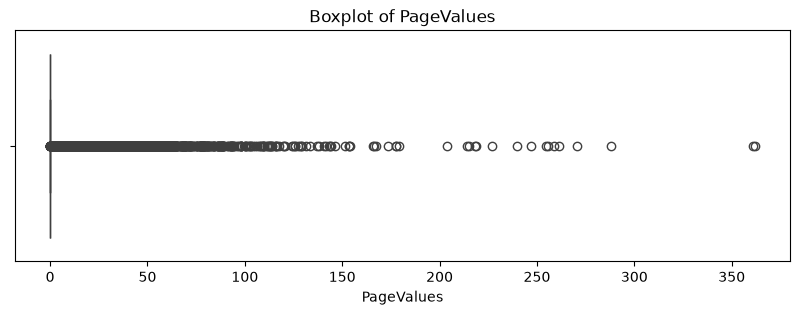

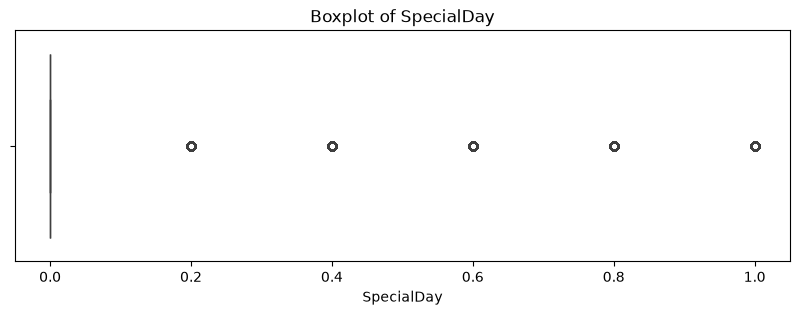

In [71]:
for column in continuous_columns:
    plt.figure(figsize=(10, 3))
    
    sns.boxplot(data=df, x=column)
    
    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)
    
    plt.show()

In [72]:
outlier_summary = []

for column in continuous_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]
    
    outlier_summary.append({
        "Feature": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers),
        "Outlier %": len(outliers) / len(df) * 100
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary.sort_values(
    by="Outlier %",
    ascending=False
)

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
8,PageValues,0.000000,0.000000,0.000000,0.000000,0.000000,2730,22.141119
2,Informational,0.000000,0.000000,0.000000,0.000000,0.000000,2631,21.338200
3,Informational_Duration,0.000000,0.000000,0.000000,0.000000,0.000000,2405,19.505272
6,BounceRates,0.000000,0.016813,0.016813,-0.025219,0.042031,1551,12.579075
9,SpecialDay,0.000000,0.000000,0.000000,0.000000,0.000000,1251,10.145985
1,Administrative_Duration,0.000000,93.256250,93.256250,-139.884375,233.140625,1172,9.505272
7,ExitRates,0.014286,0.050000,0.035714,-0.039286,0.103571,1099,8.913220
4,ProductRelated,7.000000,38.000000,31.000000,-39.500000,84.500000,987,8.004866
5,ProductRelated_Duration,184.137500,1464.157214,1280.019714,-1735.892070,3384.186784,961,7.793998
0,Administrative,0.000000,4.000000,4.000000,-6.000000,10.000000,404,3.276561


In [73]:
df[continuous_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Administrative,12330.0,2.315166,3.321784,0.0,0.000000,1.000000,4.000000,27.000000
Administrative_Duration,12330.0,80.818611,176.779107,0.0,0.000000,7.500000,93.256250,3398.750000
Informational,12330.0,0.503569,1.270156,0.0,0.000000,0.000000,0.000000,24.000000
Informational_Duration,12330.0,34.472398,140.749294,0.0,0.000000,0.000000,0.000000,2549.375000
ProductRelated,12330.0,31.731468,44.475503,0.0,7.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,12330.0,1194.746220,1913.669288,0.0,184.137500,598.936905,1464.157214,63973.522230
BounceRates,12330.0,0.022191,0.048488,0.0,0.000000,0.003112,0.016813,0.200000
ExitRates,12330.0,0.043073,0.048597,0.0,0.014286,0.025156,0.050000,0.200000
PageValues,12330.0,5.889258,18.568437,0.0,0.000000,0.000000,0.000000,361.763742
SpecialDay,12330.0,0.061427,0.198917,0.0,0.000000,0.000000,0.000000,1.000000


In [74]:
np.log1p(df["ProductRelated_Duration"])

0        0.000000
1        4.174387
2        0.000000
3        1.299283
4        6.443336
           ...   
12325    7.487057
12326    6.145794
12327    5.221706
12328    5.849325
12329    3.102342
Name: ProductRelated_Duration, Length: 12330, dtype: float64